In [64]:
import pandas as pd 
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix , r2_score
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler , LabelEncoder
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import seaborn as sns

In [7]:
purchaseDate = pd.read_csv('Purchase_Logistic.csv')

In [8]:
purchaseDate.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [9]:
purchaseDate.tail()

,User ID,Gender,Age,EstimatedSalary,Purchased
395,15691863,Female,46,41000,1
396,15706071,Male,51,23000,1
397,15654296,Female,50,20000,1
398,15755018,Male,36,33000,0
399,15594041,Female,49,36000,1


In [10]:
purchaseDate.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB


In [11]:
purchaseDate.isnull().sum()

User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

# Label Encoder 

In [50]:
le = LabelEncoder()

In [51]:
purchaseDate['Gender'] = le.fit_transform(purchaseDate['Gender'])

In [52]:
X = purchaseDate[['Age', 'EstimatedSalary']]
Y = purchaseDate[['Purchased']]

In [53]:
x_train ,x_test , y_train , y_test = train_test_split(X , Y , test_size= 0.25 , random_state= 44)

In [54]:
len(x_test) 

100

In [55]:
model = GaussianNB()

# Standard Scaler 

In [56]:
scaler = StandardScaler()

In [57]:
x_train_scaler= scaler.fit_transform(x_train)
x_test_scaler = scaler.transform(x_test)

# Train the Model

In [58]:
model.fit(x_train_scaler, y_train)

C:\Users\Charanjot Kaur\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


GaussianNB()

# Predict the data 

In [59]:
y_pred = model.predict (x_test_scaler)

# Performance `

In [60]:
# Confusion Matrix 
cm = confusion_matrix(y_pred , y_test )
cm 

array([[53,  8],
       [ 5, 34]], dtype=int64)

# Heatmap 

Text(50.72222222222221, 0.5, 'true Label')

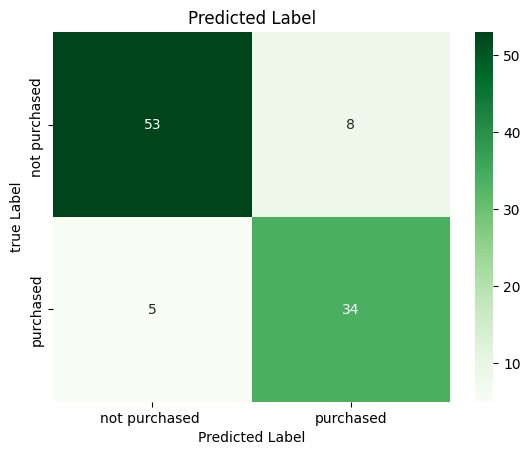

In [61]:
sns.heatmap(cm , annot = True , fmt ='d',cmap='Greens' , 
           xticklabels=['not purchased ','purchased'],
            yticklabels=['not purchased ','purchased'])
# plt.figure(figsize=(10,10))
plt.title('Predicted Label')
plt.xlabel('Predicted Label')
plt.ylabel('true Label')

# Performance Metrices

In [63]:
print('Classification Report : \n',classification_report(y_test , y_pred))

Classification Report : 
               precision    recall  f1-score   support

           0       0.87      0.91      0.89        58
           1       0.87      0.81      0.84        42

    accuracy                           0.87       100
   macro avg       0.87      0.86      0.87       100
weighted avg       0.87      0.87      0.87       100



In [65]:
r2_score(y_pred , y_test)

0.45355191256830596

C:\Users\Charanjot Kaur\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but GaussianNB was fitted without feature names
  warnings.warn(


0.42